In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    if wavelength < 380 or wavelength > 750:
        return (0.5, 0.5, 0.5)
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 < wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 < wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 < wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 < wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 < wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    return (R, G, B)

def scatter_colored(df, col_Es1, col_f, title, xlab, ylab, xlim=None):
    d = df.dropna(subset=[col_Es1, col_f]).copy()
    if d.empty:
        return
    lam = 1239.841984 / d[col_Es1].values  # eV -> nm
    colors = [wavelength_to_rgb(w) for w in lam]
    fig, ax = plt.subplots(figsize=(6.6, 5.2), dpi=300)
    ax.scatter(d[col_Es1], d[col_f], c=colors, s=10)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if xlim is not None:
        ax.set_xlim(*xlim)
    return fig, ax

In [ ]:
oled_df = pd.read_csv("training_dataset/oled_all_with_predictions.csv")
oled_df

,Unnamed: 0,smiles,absorption,splitting,rate,strength,p_gap
0,0,Cc1cc(C)c(N(c2ccc(-c3ccccc3)cc2)c2c(C)cc(C)c(-...,3.0287,0.1154,3.196360e-03,0.0021,6.513675
1,1,CSc1cc(C(=O)c2cc(C)cc(C)c2)cc(N2c3ccccc3Sc3ccc...,2.6122,0.0297,8.487561e-03,0.0003,5.887012
2,2,COC(=O)c1ccc(N2c3ccccc3N(C)c3ccccc32)cc1,2.2845,0.0181,1.189633e-01,0.0037,6.158549
3,3,COC(=O)c1cc(N2c3ccccc3N(c3c(C)c(C)cc(C)c3C)c3c...,1.9458,0.0277,8.415652e-03,0.0005,5.500644
4,4,CSc1ccc2c(c1)c1cc(-c3cc(C)cc(C)c3)ccc1n2-c1ccc...,2.3335,0.1664,1.962930e-02,0.1557,6.080150
...,...,...,...,...,...,...,...
460199,460199,c1ccc(-n2c3ccccc3c3cc4sc5ccc(-c6cc7ccccc7c7cc(...,3.4146,0.8077,3.072795e-13,0.0675,6.596650
460200,460200,O=c1ccn(-c2cc(-c3cnc4cc(-c5ccc(-c6cnccn6)cc5)c...,2.7299,0.2380,1.309420e-04,0.0121,7.614447
460201,460201,N#Cc1cc(-c2cc3c4ccccc4n(-c4ccccc4)c3cn2)c(-c2c...,3.4564,0.6539,8.942818e-13,0.0005,6.218566
460202,460202,Cc1cc(-c2cc(-c3cc(C)c4c(c3)c3ccccc3n4-c3ccccc3...,3.7043,0.9585,9.289134e-16,0.0592,6.577223


In [3]:
rafa_df = pd.read_csv("training_dataset/rafa_comp_combined.csv")
rafa_df

,smiles,gap,absorption,strength,bc_strength,log_strength
0,B1C=Cc2c(ccc3ccccc23)N1,8.073564,4.275,1.530630e-01,-1.548479,-0.815130
1,B1C=Cc2cc3c(cc2N1)C=CBN3,7.809722,4.023,2.343634e-01,-1.248980,-0.630110
2,B1C=Cc2cc3ccccc3cc2N1,7.645284,4.037,6.016749e-02,-2.117524,-1.220638
3,B1C=Cc2ccc3ccccc3c2N1,8.136231,4.239,9.202497e-02,-1.872469,-1.036094
4,B1NBNBN1,12.293560,6.983,1.662000e-06,-4.436394,-5.779369
...,...,...,...,...,...,...
41515,c1csc(Sc2cccs2)c1,9.180196,5.023,1.706031e-01,-1.474756,-0.768013
41516,c1cscn1,10.350395,5.553,6.427040e-04,-3.724094,-3.191989
41517,c1ncc2[nH]cnc2n1,9.770656,4.549,4.429358e-03,-3.221917,-2.353659
41518,c1ncc2nc[nH]c2n1,9.722410,4.621,2.553786e-03,-3.386678,-2.592815


In [17]:
# check how many oled_df smiles are in rafa_df
oled_smiles = set(oled_df["smiles"])
rafa_smiles = set(rafa_df["smiles"])
common_smiles = oled_smiles.intersection(rafa_smiles)
print(len(common_smiles)/len(rafa_smiles))
print(len(common_smiles)/len(oled_smiles)) 
print(len(common_smiles))

0.25515414258188823
0.023020325856906314
10594


In [13]:
smiles_1 = list(common_smiles)[2]
print(smiles_1)
oled_row = oled_df[oled_df["smiles"] == smiles_1]
rafa_row = rafa_df[rafa_df["smiles"] == smiles_1]
print(oled_row)
print(rafa_row)

COC=C/C(OC)=C(\Cl)C=NCl
        Unnamed: 0                   smiles  absorption  splitting  \
449733      449733  COC=C/C(OC)=C(\Cl)C=NCl      4.1342     2.0815   

                rate  strength     p_gap  
449733  2.339616e-33    0.8781  6.110446  
                        smiles       gap  absorption  strength  bc_strength  \
19079  COC=C/C(OC)=C(\Cl)C=NCl  4.029949      4.1342    0.8781     -0.12822   

       log_strength  
19079     -0.056456  


In [14]:
## concatenate the two dataframes without duplicates
combined_df = pd.concat([oled_df, rafa_df]).drop_duplicates(subset=["smiles"])
combined_df

,Unnamed: 0,smiles,absorption,splitting,rate,strength,p_gap,gap,bc_strength,log_strength
0,0.0,Cc1cc(C)c(N(c2ccc(-c3ccccc3)cc2)c2c(C)cc(C)c(-...,3.0287,0.1154,0.003196,0.002100,6.513675,NaN,NaN,NaN
1,1.0,CSc1cc(C(=O)c2cc(C)cc(C)c2)cc(N2c3ccccc3Sc3ccc...,2.6122,0.0297,0.008488,0.000300,5.887012,NaN,NaN,NaN
2,2.0,COC(=O)c1ccc(N2c3ccccc3N(C)c3ccccc32)cc1,2.2845,0.0181,0.118963,0.003700,6.158549,NaN,NaN,NaN
3,3.0,COC(=O)c1cc(N2c3ccccc3N(c3c(C)c(C)cc(C)c3C)c3c...,1.9458,0.0277,0.008416,0.000500,5.500644,NaN,NaN,NaN
4,4.0,CSc1ccc2c(c1)c1cc(-c3cc(C)cc(C)c3)ccc1n2-c1ccc...,2.3335,0.1664,0.019629,0.155700,6.080150,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
41512,NaN,c1csc(-n2c3ccccc3c3ccccc32)c1,4.4790,NaN,NaN,0.053252,NaN,8.454468,-2.183954,-1.273667
41513,NaN,c1csc(CN[C@@H]2CCCC[C@H]2NCc2cccs2)c1,5.5890,NaN,NaN,0.065800,NaN,9.494216,-2.067735,-1.181774
41514,NaN,c1csc(SSc2cccs2)c1,3.1640,NaN,NaN,0.007152,NaN,7.962051,-3.062046,-2.145567
41515,NaN,c1csc(Sc2cccs2)c1,5.0230,NaN,NaN,0.170603,NaN,9.180196,-1.474756,-0.768013


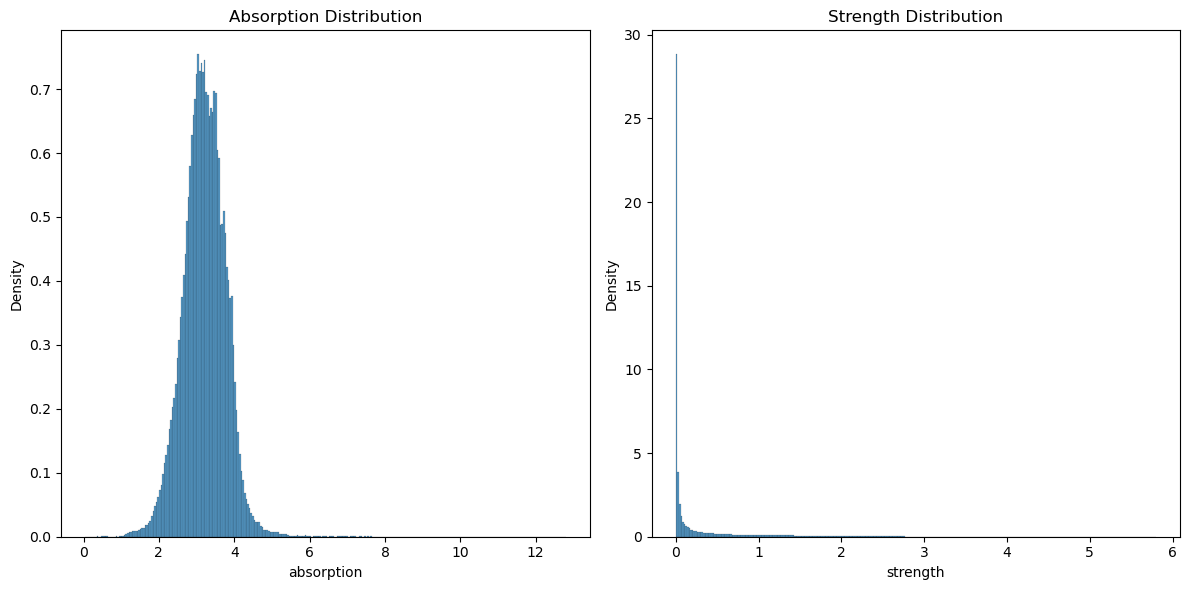

In [22]:
# plot the histogram density for absorption and strength for the combined dataframe
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(combined_df["absorption"], bins=300, kde=False, stat="density")
plt.title("Absorption Distribution")
plt.subplot(1, 2, 2)
sns.histplot(combined_df["strength"], bins=300, kde=False, stat="density")
plt.title("Strength Distribution")
plt.tight_layout()
plt.show()

In [23]:
## print min and max for absorption and strength
print("Absorption min:", combined_df["absorption"].min())
print("Absorption max:", combined_df["absorption"].max())
print("Strength min:", combined_df["strength"].min())
print("Strength max:", combined_df["strength"].max())

Absorption min: 0.049
Absorption max: 12.796
Strength min: 0.0
Strength max: 5.799043839


In [26]:
# compute the quantiles for 20th, 40th, 60th, 80th percentiles for absorption and strength
absorption_quantiles = combined_df["absorption"].quantile([0.2, 0.4, 0.6, 0.8])
strength_quantiles = combined_df["strength"].quantile([0.2, 0.4, 0.6, 0.8])
print("Absorption quantiles:")
print(absorption_quantiles)
print("Strength quantiles:")
print(strength_quantiles)

Absorption quantiles:
0.2    2.7655
0.4    3.0720
0.6    3.3521
0.8    3.6723
Name: absorption, dtype: float64
Strength quantiles:
0.2    0.000500
0.4    0.004600
0.6    0.028595
0.8    0.294600
Name: strength, dtype: float64


In [2]:
val_df = pd.read_csv("results/validation/td-dft/VEE_wb97x-D3.csv")
val_df

,mol,smiles,E_S1(eV),wl_S1(nm),osc_S1,E_S2(eV),wl_S2(nm),osc_S2,E_S3(eV),wl_S3(nm),...,osc_S1_SOC,E_S2_SOC(eV),wl_S2_SOC(nm),osc_S2_SOC,E_S3_SOC(eV),wl_S3_SOC(nm),osc_S3_SOC,HOMO(eV),LUMO(eV),Gap(eV)
0,mol0001,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,3.484232,355.8,1.555150,4.671025,265.4,0.004173,5.032897,246.3,...,1.555150,4.671025,265.4,0.004173,5.032898,246.3,0.000104,-7.7595,-0.7950,6.96
1,mol0004,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,3.921178,316.2,0.221071,4.145382,299.1,0.280226,4.472756,277.2,...,0.221071,4.145382,299.1,0.280226,4.472756,277.2,0.337075,-6.7767,1.0679,7.84
2,mol0005,Cc1cc(-c2ccccc2)c2ccccc2c1,4.597870,269.7,0.076768,4.721513,262.6,0.280983,5.423316,228.6,...,0.076768,4.721513,262.6,0.280983,5.423316,228.6,0.002020,-7.9701,0.5248,8.49
3,mol0006,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,4.148900,298.8,0.047076,4.192487,295.7,0.048159,4.373187,283.5,...,0.047076,4.192487,295.7,0.048159,4.373187,283.5,0.034729,-7.1452,0.3776,7.52
4,mol0007,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,4.536639,273.3,0.007779,4.555223,272.2,0.019595,4.620552,268.3,...,0.007779,4.555223,272.2,0.019595,4.620552,268.3,0.002269,-7.2822,0.4573,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,mol1785,COC(=O)c1ccc(C)cc1,5.236681,236.8,0.014326,5.453252,227.4,0.000490,5.600300,221.4,...,0.014326,5.453255,227.4,0.000490,5.600300,221.4,0.532561,-9.2307,0.5082,9.74
454,mol1787,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,5.145753,240.9,0.027909,5.467144,226.8,0.271576,5.673112,218.5,...,0.027909,5.467144,226.8,0.271577,5.673114,218.5,0.017089,-8.2088,1.4654,9.67
455,mol1793,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,1.670407,742.2,0.010177,3.337971,371.4,0.750232,4.090485,303.1,...,0.010177,3.337971,371.4,0.750232,4.090486,303.1,0.000009,-7.8016,-1.6275,6.17
456,mol1795,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,2.288210,541.8,0.040712,3.647002,340.0,0.469434,3.925125,315.9,...,0.040712,3.647002,340.0,0.469434,3.925125,315.9,0.621733,-7.9761,-1.7586,6.22


In [29]:
val_df.columns

Index(['mol', 'smiles', 'E_S1(eV)', 'wl_S1(nm)', 'osc_S1', 'E_S2(eV)',
       'wl_S2(nm)', 'osc_S2', 'E_S3(eV)', 'wl_S3(nm)', 'osc_S3', 'E_T1(eV)',
       'E_T2(eV)', 'E(S1-T1)(eV)', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)',
       'osc_S1_SOC', 'E_S2_SOC(eV)', 'wl_S2_SOC(nm)', 'osc_S2_SOC',
       'E_S3_SOC(eV)', 'wl_S3_SOC(nm)', 'osc_S3_SOC', 'HOMO(eV)', 'LUMO(eV)',
       'Gap(eV)'],
      dtype='object')

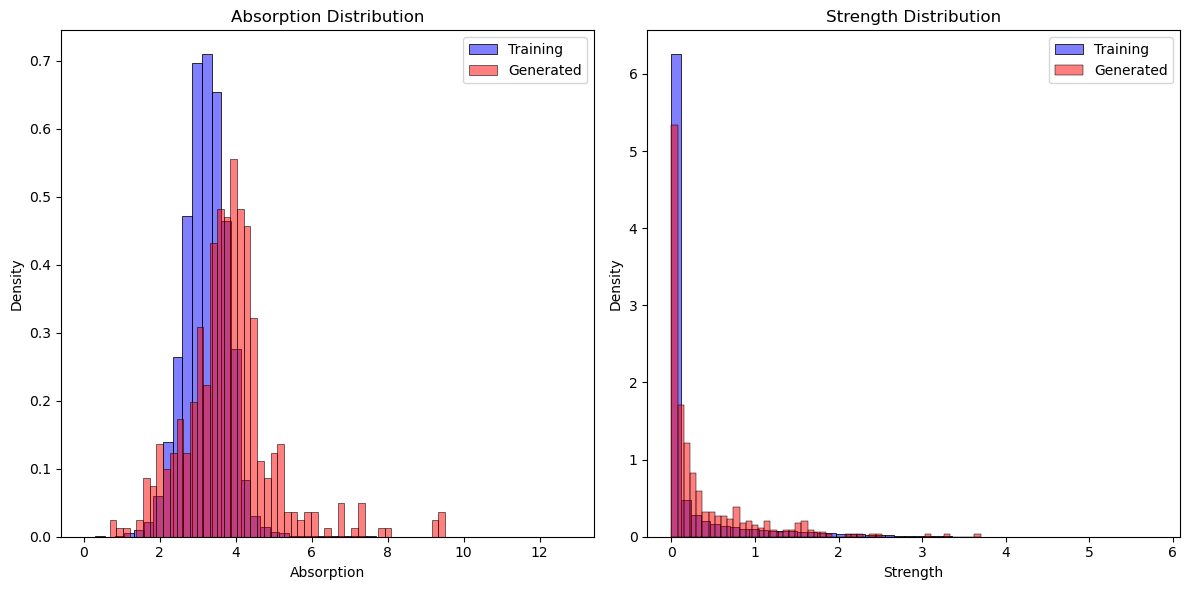

In [ ]:
# do the plot of the histogram density for the training set combined_df and the validation set val_df for absorption and strength
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(combined_df["absorption"], bins=50, kde=False, stat="density", label="Training", color="blue", alpha=0.5)
sns.histplot(val_df["E_S1_SOC(eV)"], bins=50, kde=False, stat="density", label="Generated", color="red", alpha=0.5)
plt.xlabel("Absorption")
plt.ylabel("Density")
plt.title("Absorption Distribution")
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(combined_df["strength"], bins=50, kde=False, stat="density", label="Training", color="blue", alpha=0.5)
sns.histplot(val_df["osc_S1_SOC"], bins=50, kde=False, stat="density", label="Generated", color="red", alpha=0.5)
plt.xlabel("Strength")
plt.ylabel("Density")
plt.title("Strength Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
## compute number of benzene rings and heavy atoms in the combined_df and val_df and plot the distribution
from rdkit import Chem
def count_benzene_rings(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return mol.GetRingInfo().NumRings()
    else:
        return 0
def count_heavy_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return len([atom for atom in mol.GetAtoms() if atom.GetAtomicNum() > 1])
    else:
        return 0
## add progress bar to apply functions to the dataframes
from tqdm import tqdm
tqdm.pandas()
combined_df["benzene_rings"] = combined_df["smiles"].progress_apply(count_benzene_rings)
combined_df["heavy_atoms"] = combined_df["smiles"].progress_apply(count_heavy_atoms)
val_df["benzene_rings"] = val_df["smiles"].progress_apply(count_benzene_rings)
val_df["heavy_atoms"] = val_df["smiles"].progress_apply(count_heavy_atoms)


100%|██████████| 458/458 [00:00<00:00, 3105.32it/s]


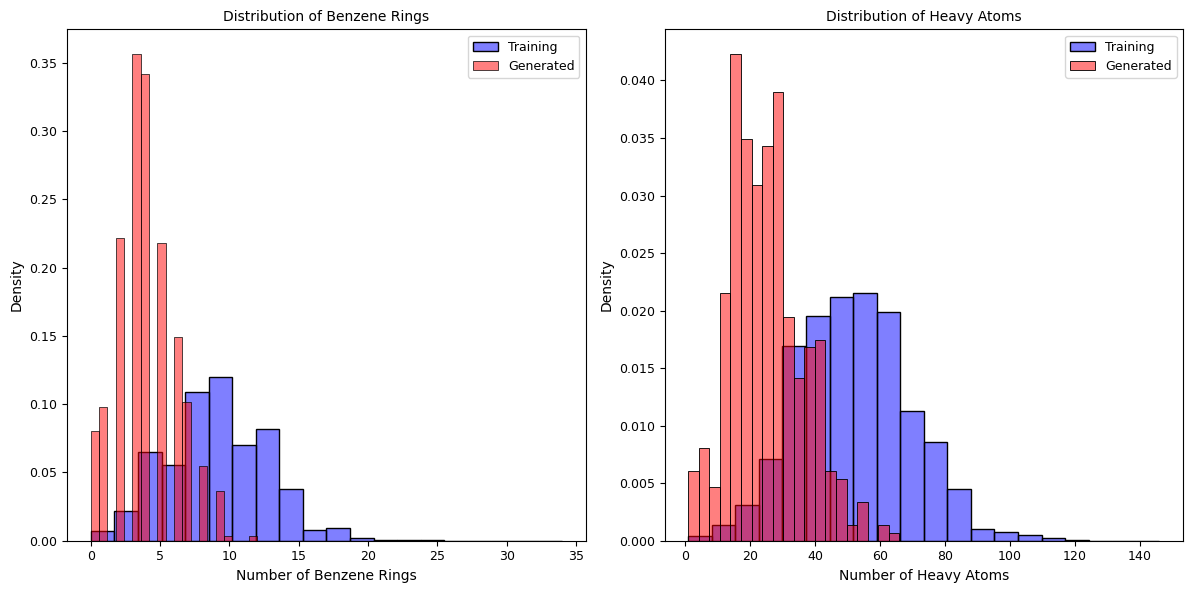

In [50]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
bins = 20
sns.histplot(combined_df["benzene_rings"], bins=bins, kde=False, label="Training", color="blue", alpha=0.5, stat="density")
sns.histplot(val_df["benzene_rings"], bins=bins, kde=False, label="Generated", color="red", alpha=0.5, stat="density")
plt.xlabel("Number of Benzene Rings")
plt.ylabel("Density")
plt.title("Distribution of Benzene Rings")
plt.legend()
plt.subplot(1, 2, 2)
sns.histplot(combined_df["heavy_atoms"], bins=bins, kde=False, label="Training", color="blue", alpha=0.5, stat="density")
sns.histplot(val_df["heavy_atoms"], bins=bins, kde=False, label="Generated", color="red", alpha=0.5, stat="density")
plt.xlabel("Number of Heavy Atoms")
plt.ylabel("Density")

plt.title("Distribution of Heavy Atoms")
plt.legend()
plt.tight_layout()
plt.show()

100%|██████████| 458/458 [00:00<00:00, 3914.76it/s]


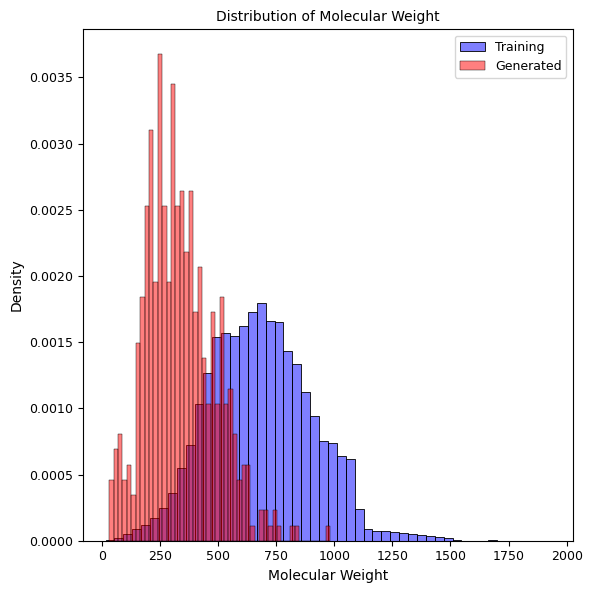

In [103]:
## also do the plot for molecular weight distribution for the combined_df and val_df
from rdkit.Chem import Descriptors
def compute_molecular_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return Descriptors.MolWt(mol)
    else:
        return 0
combined_df["molecular_weight"] = combined_df["smiles"].progress_apply(compute_molecular_weight)
val_df["molecular_weight"] = val_df["smiles"].progress_apply(compute_molecular_weight)
plt.figure(figsize=(6, 6))
sns.histplot(combined_df["molecular_weight"], bins=50, kde=False, label="Training", color="blue", alpha=0.5, stat="density")
sns.histplot(val_df["molecular_weight"], bins=50, kde=False, label="Generated", color="red", alpha=0.5, stat="density")
plt.xlabel("Molecular Weight")
plt.ylabel("Density")
plt.title("Distribution of Molecular Weight")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
### do a publication

## save processed csv's 

In [104]:
path = 'plots_for_manuscript/training_and_generated'

combined_df.to_csv(f'{path}/combined_training_data.csv', index=False)
val_df.to_csv(f'{path}/generated_validation_data.csv', index=False)

In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Prepare output directory
# ------------------------------------------------------------------
path = "plots_for_manuscript/training_and_generated"
os.makedirs(path, exist_ok=True)
outfile = os.path.join(path, "training_vs_generated_distributions.pdf")

# ------------------------------------------------------------------
# Helper for consistent binning
# ------------------------------------------------------------------
def _common_bins(x_train, x_gen, bins=50):
    x = np.concatenate([np.asarray(x_train, dtype=float),
                        np.asarray(x_gen, dtype=float)])
    x = x[np.isfinite(x)]
    xmin, xmax = np.min(x), np.max(x)
    if np.isclose(xmin, xmax):
        xmin -= 0.5
        xmax += 0.5
    return np.linspace(xmin, xmax, bins + 1)

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
train_abs = combined_df["absorption"].to_numpy()
gen_abs   = val_df["E_S1_SOC(eV)"].to_numpy()

train_str = combined_df["strength"].to_numpy()
gen_str   = val_df["osc_S1_SOC"].to_numpy()

train_bz  = combined_df["benzene_rings"].to_numpy()
gen_bz    = val_df["benzene_rings"].to_numpy()

train_ha  = combined_df["heavy_atoms"].to_numpy()
gen_ha    = val_df["heavy_atoms"].to_numpy()

# ------------------------------------------------------------------
# Publication-quality style
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.8), constrained_layout=True)

panels = [
    (axes[0, 0], train_abs, gen_abs, 50, "Absorption energy (eV)", ""),
    (axes[0, 1], train_str, gen_str, 50, "Oscillator strength", ""),
    (axes[1, 0], train_bz,  gen_bz,  20, "Number of rings", ""),
    (axes[1, 1], train_ha,  gen_ha,  20, "Number of heavy atoms", ""),
]

for ax, x_tr, x_ge, nbins, xlabel, title in panels:
    bins = _common_bins(x_tr, x_ge, bins=nbins)

    ax.hist(x_tr, bins=bins, density=True, alpha=0.45, label="Training")
    ax.hist(x_ge, bins=bins, density=True, alpha=0.45, label="Generated")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------------
# Save high-resolution vector PDF
# ------------------------------------------------------------------
fig.savefig(outfile, format="pdf", dpi=200, bbox_inches="tight", transparent=True)
plt.close(fig)

In [106]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Prepare output directory
# ------------------------------------------------------------------
path = "plots_for_manuscript/training_and_generated"
os.makedirs(path, exist_ok=True)
outfile = os.path.join(path, "training_vs_generated_distributions_mw.pdf")

# ------------------------------------------------------------------
# Helper for consistent binning
# ------------------------------------------------------------------
def _common_bins(x_train, x_gen, bins=50):
    x = np.concatenate([np.asarray(x_train, dtype=float),
                        np.asarray(x_gen, dtype=float)])
    x = x[np.isfinite(x)]
    xmin, xmax = np.min(x), np.max(x)
    if np.isclose(xmin, xmax):
        xmin -= 0.5
        xmax += 0.5
    return np.linspace(xmin, xmax, bins + 1)

# ------------------------------------------------------------------
# Data
# ------------------------------------------------------------------
train_abs = combined_df["absorption"].to_numpy()
gen_abs   = val_df["E_S1_SOC(eV)"].to_numpy()

train_str = combined_df["strength"].to_numpy()
gen_str   = val_df["osc_S1_SOC"].to_numpy()

train_bz  = combined_df["molecular_weight"].to_numpy()
gen_bz    = val_df["molecular_weight"].to_numpy()

train_ha  = combined_df["heavy_atoms"].to_numpy()
gen_ha    = val_df["heavy_atoms"].to_numpy()

# ------------------------------------------------------------------
# Publication-quality style
# ------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.8), constrained_layout=True)

panels = [
    (axes[0, 0], train_abs, gen_abs, 50, "Absorption energy (eV)", ""),
    (axes[0, 1], train_str, gen_str, 50, "Oscillator strength", ""),
    (axes[1, 0], train_bz,  gen_bz,  50, "Molecular weight", ""),
    (axes[1, 1], train_ha,  gen_ha,  50, "Number of heavy atoms", ""),
]

for ax, x_tr, x_ge, nbins, xlabel, title in panels:
    bins = _common_bins(x_tr, x_ge, bins=nbins)

    ax.hist(x_tr, bins=bins, density=True, alpha=0.45, label="Training")
    ax.hist(x_ge, bins=bins, density=True, alpha=0.45, label="Generated")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------------
# Save high-resolution vector PDF
# ------------------------------------------------------------------
fig.savefig(outfile, format="pdf", dpi=200, bbox_inches="tight", transparent=True)
plt.close(fig)

# Study how absorption and oscillator strength change with token

In [52]:
val_df.columns

Index(['mol', 'smiles', 'E_S1(eV)', 'wl_S1(nm)', 'osc_S1', 'E_S2(eV)',
       'wl_S2(nm)', 'osc_S2', 'E_S3(eV)', 'wl_S3(nm)', 'osc_S3', 'E_T1(eV)',
       'E_T2(eV)', 'E(S1-T1)(eV)', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)',
       'osc_S1_SOC', 'E_S2_SOC(eV)', 'wl_S2_SOC(nm)', 'osc_S2_SOC',
       'E_S3_SOC(eV)', 'wl_S3_SOC(nm)', 'osc_S3_SOC', 'HOMO(eV)', 'LUMO(eV)',
       'Gap(eV)', 'benzene_rings', 'heavy_atoms'],
      dtype='object')

In [55]:
std2_df = pd.read_csv("results/validation/std2/std2.csv")
std2_df

,partition,mol,smiles,strength,absorption,E_S1_eV,E_T1_eV,E_ST_eV,f_osc_S1,token
0,partition_0,mol0001,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,0,0,3.1183,2.0336,1.0847,1.762547,str_0_abs_0
1,partition_0,mol0004,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,0,0,3.0243,2.6489,0.3754,0.115084,str_0_abs_0
2,partition_0,mol0005,Cc1cc(-c2ccccc2)c2ccccc2c1,0,0,4.1843,3.3440,0.8403,0.005298,str_0_abs_0
3,partition_0,mol0006,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,0,0,3.2248,2.8290,0.3958,0.010807,str_0_abs_0
4,partition_0,mol0007,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,0,0,3.9926,3.4429,0.5497,0.072529,str_0_abs_0
...,...,...,...,...,...,...,...,...,...,...
495,partition_1,mol1785,COC(=O)c1ccc(C)cc1,4,4,4.6919,4.2582,0.4337,0.017268,str_4_abs_4
496,partition_1,mol1787,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,4,4,4.4436,4.0198,0.4238,0.026054,str_4_abs_4
497,partition_1,mol1793,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,4,4,0.6178,0.2721,0.3457,0.001917,str_4_abs_4
498,partition_1,mol1795,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,4,4,1.3097,0.9405,0.3692,0.018054,str_4_abs_4


In [76]:
token_df = val_df[["smiles", "E_S1_SOC(eV)", "osc_S1_SOC"]].copy()
# merge strength token, absorption token and token from std2_df into token_df and using smiles as key and call it cond_strength and cond_absorption and cond_token
token_df = token_df.merge(std2_df[["smiles", "token", "strength", "absorption"]], on="smiles", how="left")
token_df["cond_token"] = token_df["token"]
token_df["cond_strength"] = token_df["strength"]
token_df["cond_absorption"] = token_df["absorption"]
token_df

,smiles,E_S1_SOC(eV),osc_S1_SOC,token,strength,absorption,cond_token,cond_strength,cond_absorption
0,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,3.484232,1.555150,str_0_abs_0,0,0,str_0_abs_0,0,0
1,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,3.921178,0.221071,str_0_abs_0,0,0,str_0_abs_0,0,0
2,Cc1cc(-c2ccccc2)c2ccccc2c1,4.597870,0.076768,str_0_abs_0,0,0,str_0_abs_0,0,0
3,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,4.148900,0.047076,str_0_abs_0,0,0,str_0_abs_0,0,0
4,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,4.536639,0.007779,str_0_abs_0,0,0,str_0_abs_0,0,0
...,...,...,...,...,...,...,...,...,...
453,COC(=O)c1ccc(C)cc1,5.236681,0.014326,str_4_abs_4,4,4,str_4_abs_4,4,4
454,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,5.145753,0.027909,str_4_abs_4,4,4,str_4_abs_4,4,4
455,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,1.670407,0.010177,str_4_abs_4,4,4,str_4_abs_4,4,4
456,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,2.288210,0.040712,str_4_abs_4,4,4,str_4_abs_4,4,4


Cond Absorption: 0, Median E_S1_SOC(eV): 3.469065
Cond Absorption: 1, Median E_S1_SOC(eV): 3.594485
Cond Absorption: 2, Median E_S1_SOC(eV): 3.641685
Cond Absorption: 3, Median E_S1_SOC(eV): 3.90572
Cond Absorption: 4, Median E_S1_SOC(eV): 4.601228000000001


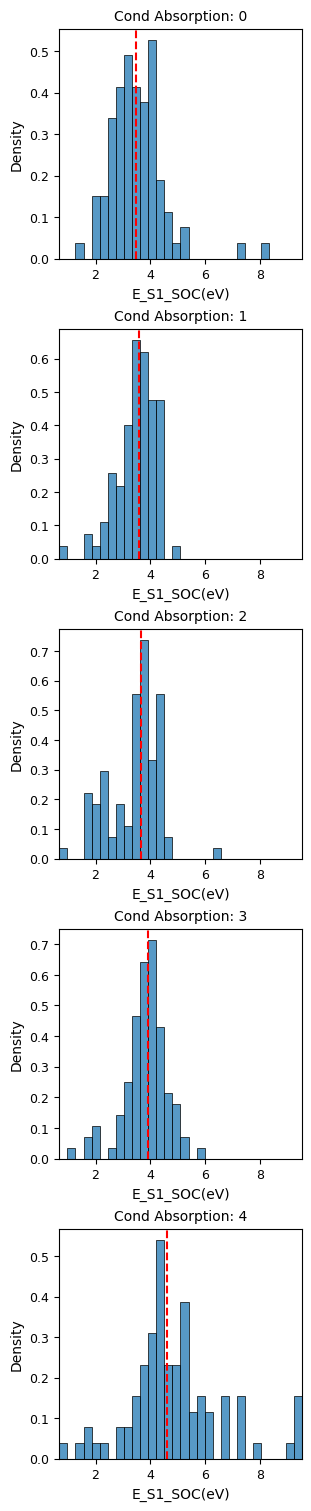

In [86]:
# plot 1,5 plot with histograms of E_S1_SOC(eV), one row per cond_adsorption value
# fix the x range for the calculation of the bins to be the same for all the plots
# also to share the size of the bins across all the plots, compute the bins for the whole dataset and then use the same bins for all the plots
# put a red dashed vertical line in the median value of E_S1_SOC(eV) for each cond_absorption value


fig, ax = plt.subplots(5, 1, figsize=(3, 15), constrained_layout=True)
x_min = token_df["E_S1_SOC(eV)"].min()
x_max = token_df["E_S1_SOC(eV)"].max()
bins = np.linspace(x_min, x_max, 31)
for i, cond_value in enumerate(sorted(token_df["cond_absorption"].unique())):
    subset = token_df[token_df["cond_absorption"] == cond_value]
    sns.histplot(subset["E_S1_SOC(eV)"], bins=bins, kde=False, stat="density", ax=ax[i])
    ax[i].set_title(f"Cond Absorption: {cond_value}")
    ax[i].set_xlabel("E_S1_SOC(eV)")
    median_value = subset["E_S1_SOC(eV)"].median()
    print(f"Cond Absorption: {cond_value}, Median E_S1_SOC(eV): {median_value}")
    ax[i].axvline(median_value, color='red', linestyle='--')
    ax[i].set_xlim(x_min, x_max)
    ax[i].set_ylabel("Density")
plt.show()




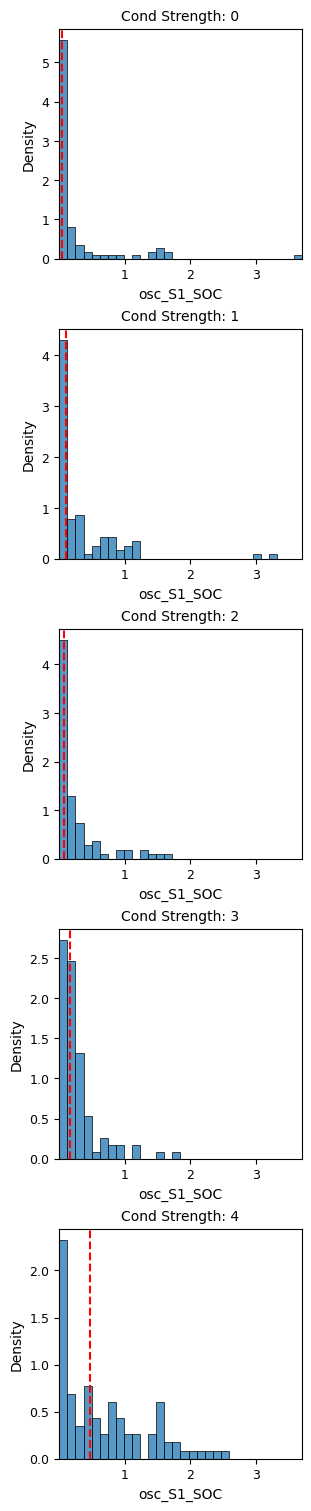

In [79]:
# do the same plot for osc_S1_SOC and cond_strength
fig, ax = plt.subplots(5, 1, figsize=(3, 15), constrained_layout=True)
x_min = token_df["osc_S1_SOC"].min()
x_max = token_df["osc_S1_SOC"].max()
bins = np.linspace(x_min, x_max, 31)
for i, cond_value in enumerate(sorted(token_df["cond_strength"].unique())):
    subset = token_df[token_df["cond_strength"] == cond_value]
    sns.histplot(subset["osc_S1_SOC"], bins=bins, kde=False, stat="density", ax=ax[i])
    ax[i].set_title(f"Cond Strength: {cond_value}")
    ax[i].set_xlabel("osc_S1_SOC")
    median_value = subset["osc_S1_SOC"].median()
    ax[i].axvline(median_value, color='red', linestyle='--')
    ax[i].set_xlim(x_min, x_max)
    ax[i].set_ylabel("Density")
plt.show()

In [83]:
# make a table with the number of data points for each cond_absorption value and the number of data points for each cond_strength value
count_table = pd.DataFrame({
    "cond_absorption": sorted(token_df["cond_absorption"].unique()),
    "count_E_S1_SOC(eV)": [token_df[token_df["cond_absorption"] == val].shape[0] for val in sorted(token_df["cond_absorption"].unique())],
    "cond_strength": sorted(token_df["cond_strength"].unique()),
    "count_osc_S1_SOC": [token_df[token_df["cond_strength"] == val].shape[0] for val in sorted(token_df["cond_strength"].unique())]
})
count_table

,cond_absorption,count_E_S1_SOC(eV),cond_strength,count_osc_S1_SOC
0,0,90,0,90
1,1,93,1,94
2,2,92,2,88
3,3,95,3,92
4,4,88,4,94


In [84]:
# make a table with the median E_S1_SOC(eV) value for each cond_absorption value and the median osc_S1_SOC value for each cond_strength value
median_table = pd.DataFrame({
    "cond_absorption": sorted(token_df["cond_absorption"].unique()),
    "median_E_S1_SOC(eV)": [token_df[token_df["cond_absorption"] == val]["E_S1_SOC(eV)"].median() for val in sorted(token_df["cond_absorption"].unique())],
    "cond_strength": sorted(token_df["cond_strength"].unique()),
    "median_osc_S1_SOC": [token_df[token_df["cond_strength"] == val]["osc_S1_SOC"].median() for val in sorted(token_df["cond_strength"].unique())]
})
median_table

,cond_absorption,median_E_S1_SOC(eV),cond_strength,median_osc_S1_SOC
0,0,3.469065,0,0.043016
1,1,3.594485,1,0.106904
2,2,3.641685,2,0.069251
3,3,3.905720,3,0.158397
4,4,4.601228,4,0.465401


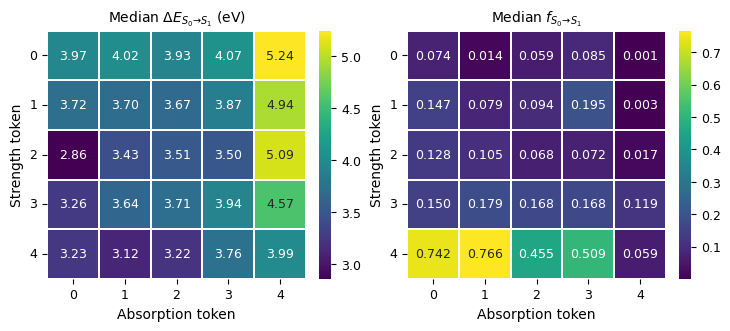

In [101]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- robust aggregation (numeric only) ---
heatmap_data = (
    token_df
    .groupby(["cond_absorption", "cond_strength"], as_index=False)
    .median(numeric_only=True)
)

E_col = "E_S1_SOC(eV)"
osc_col = "osc_S1_SOC"

# --- pivots: y = cond_strength, x = cond_absorption ---
heatmap_E = heatmap_data.pivot(index="cond_strength", columns="cond_absorption", values=E_col)
heatmap_osc = heatmap_data.pivot(index="cond_strength", columns="cond_absorption", values=osc_col)

# --- ensure consistent ordering of bins ---
x_order = sorted(heatmap_E.columns)
y_order = sorted(heatmap_E.index)

heatmap_E = heatmap_E.loc[y_order, x_order]
heatmap_osc = heatmap_osc.loc[y_order, x_order]

# --- style ---
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
})

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), constrained_layout=True)

# Left: median excitation energy
ax = axes[0]
sns.heatmap(
    heatmap_E,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    
)
ax.set_title(r"Median $\Delta E_{S_0\!\to\!S_1}$ (eV)")
ax.set_xlabel(r"Absorption token")
ax.set_ylabel(r"Strength token")
ax.set_xticklabels([int(v) for v in heatmap_E.columns], rotation=0)
ax.set_yticklabels([int(v) for v in heatmap_E.index], rotation=0)

# Right: median oscillator strength
ax = axes[1]
sns.heatmap(
    heatmap_osc,
    ax=ax,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    
)
ax.set_title(r"Median $f_{S_0\!\to\!S_1}$")
ax.set_xlabel(r"Absorption token")
ax.set_ylabel(r"Strength token")
ax.set_xticklabels([int(v) for v in heatmap_osc.columns], rotation=0)
ax.set_yticklabels([int(v) for v in heatmap_osc.index], rotation=0)

# --- save (vector PDF) ---
outdir = "plots_for_manuscript/validation_heatmaps"
os.makedirs(outdir, exist_ok=True)
fig.savefig(os.path.join(outdir, "median_heatmaps.pdf"), bbox_inches="tight")

plt.show()

## plot distribution of molecules

In [3]:
val_df = pd.read_csv("results/validation/td-dft/VEE_wb97x-D3.csv")
val_df

,mol,smiles,E_S1(eV),wl_S1(nm),osc_S1,E_S2(eV),wl_S2(nm),osc_S2,E_S3(eV),wl_S3(nm),...,osc_S1_SOC,E_S2_SOC(eV),wl_S2_SOC(nm),osc_S2_SOC,E_S3_SOC(eV),wl_S3_SOC(nm),osc_S3_SOC,HOMO(eV),LUMO(eV),Gap(eV)
0,mol0001,CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...,3.484232,355.8,1.555150,4.671025,265.4,0.004173,5.032897,246.3,...,1.555150,4.671025,265.4,0.004173,5.032898,246.3,0.000104,-7.7595,-0.7950,6.96
1,mol0004,c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...,3.921178,316.2,0.221071,4.145382,299.1,0.280226,4.472756,277.2,...,0.221071,4.145382,299.1,0.280226,4.472756,277.2,0.337075,-6.7767,1.0679,7.84
2,mol0005,Cc1cc(-c2ccccc2)c2ccccc2c1,4.597870,269.7,0.076768,4.721513,262.6,0.280983,5.423316,228.6,...,0.076768,4.721513,262.6,0.280983,5.423316,228.6,0.002020,-7.9701,0.5248,8.49
3,mol0006,CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...,4.148900,298.8,0.047076,4.192487,295.7,0.048159,4.373187,283.5,...,0.047076,4.192487,295.7,0.048159,4.373187,283.5,0.034729,-7.1452,0.3776,7.52
4,mol0007,CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...,4.536639,273.3,0.007779,4.555223,272.2,0.019595,4.620552,268.3,...,0.007779,4.555223,272.2,0.019595,4.620552,268.3,0.002269,-7.2822,0.4573,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
453,mol1785,COC(=O)c1ccc(C)cc1,5.236681,236.8,0.014326,5.453252,227.4,0.000490,5.600300,221.4,...,0.014326,5.453255,227.4,0.000490,5.600300,221.4,0.532561,-9.2307,0.5082,9.74
454,mol1787,CCCCCc1ccc(CCC)c2c1[C@@H](CCCCC)CC(=O)N2,5.145753,240.9,0.027909,5.467144,226.8,0.271576,5.673112,218.5,...,0.027909,5.467144,226.8,0.271577,5.673114,218.5,0.017089,-8.2088,1.4654,9.67
455,mol1793,C(#Cc1ccncc1)C1=C2C=CC=C2C=C1,1.670407,742.2,0.010177,3.337971,371.4,0.750232,4.090485,303.1,...,0.010177,3.337971,371.4,0.750232,4.090486,303.1,0.000009,-7.8016,-1.6275,6.17
456,mol1795,O=C1C=c2c(c3c(c4ccccc24)=CC=C3)O1,2.288210,541.8,0.040712,3.647002,340.0,0.469434,3.925125,315.9,...,0.040712,3.647002,340.0,0.469434,3.925125,315.9,0.621733,-7.9761,-1.7586,6.22


In [5]:
print(val_df.columns)

Index(['mol', 'smiles', 'E_S1(eV)', 'wl_S1(nm)', 'osc_S1', 'E_S2(eV)',
       'wl_S2(nm)', 'osc_S2', 'E_S3(eV)', 'wl_S3(nm)', 'osc_S3', 'E_T1(eV)',
       'E_T2(eV)', 'E(S1-T1)(eV)', 'E_S1_SOC(eV)', 'wl_S1_SOC(nm)',
       'osc_S1_SOC', 'E_S2_SOC(eV)', 'wl_S2_SOC(nm)', 'osc_S2_SOC',
       'E_S3_SOC(eV)', 'wl_S3_SOC(nm)', 'osc_S3_SOC', 'HOMO(eV)', 'LUMO(eV)',
       'Gap(eV)'],
      dtype='object')


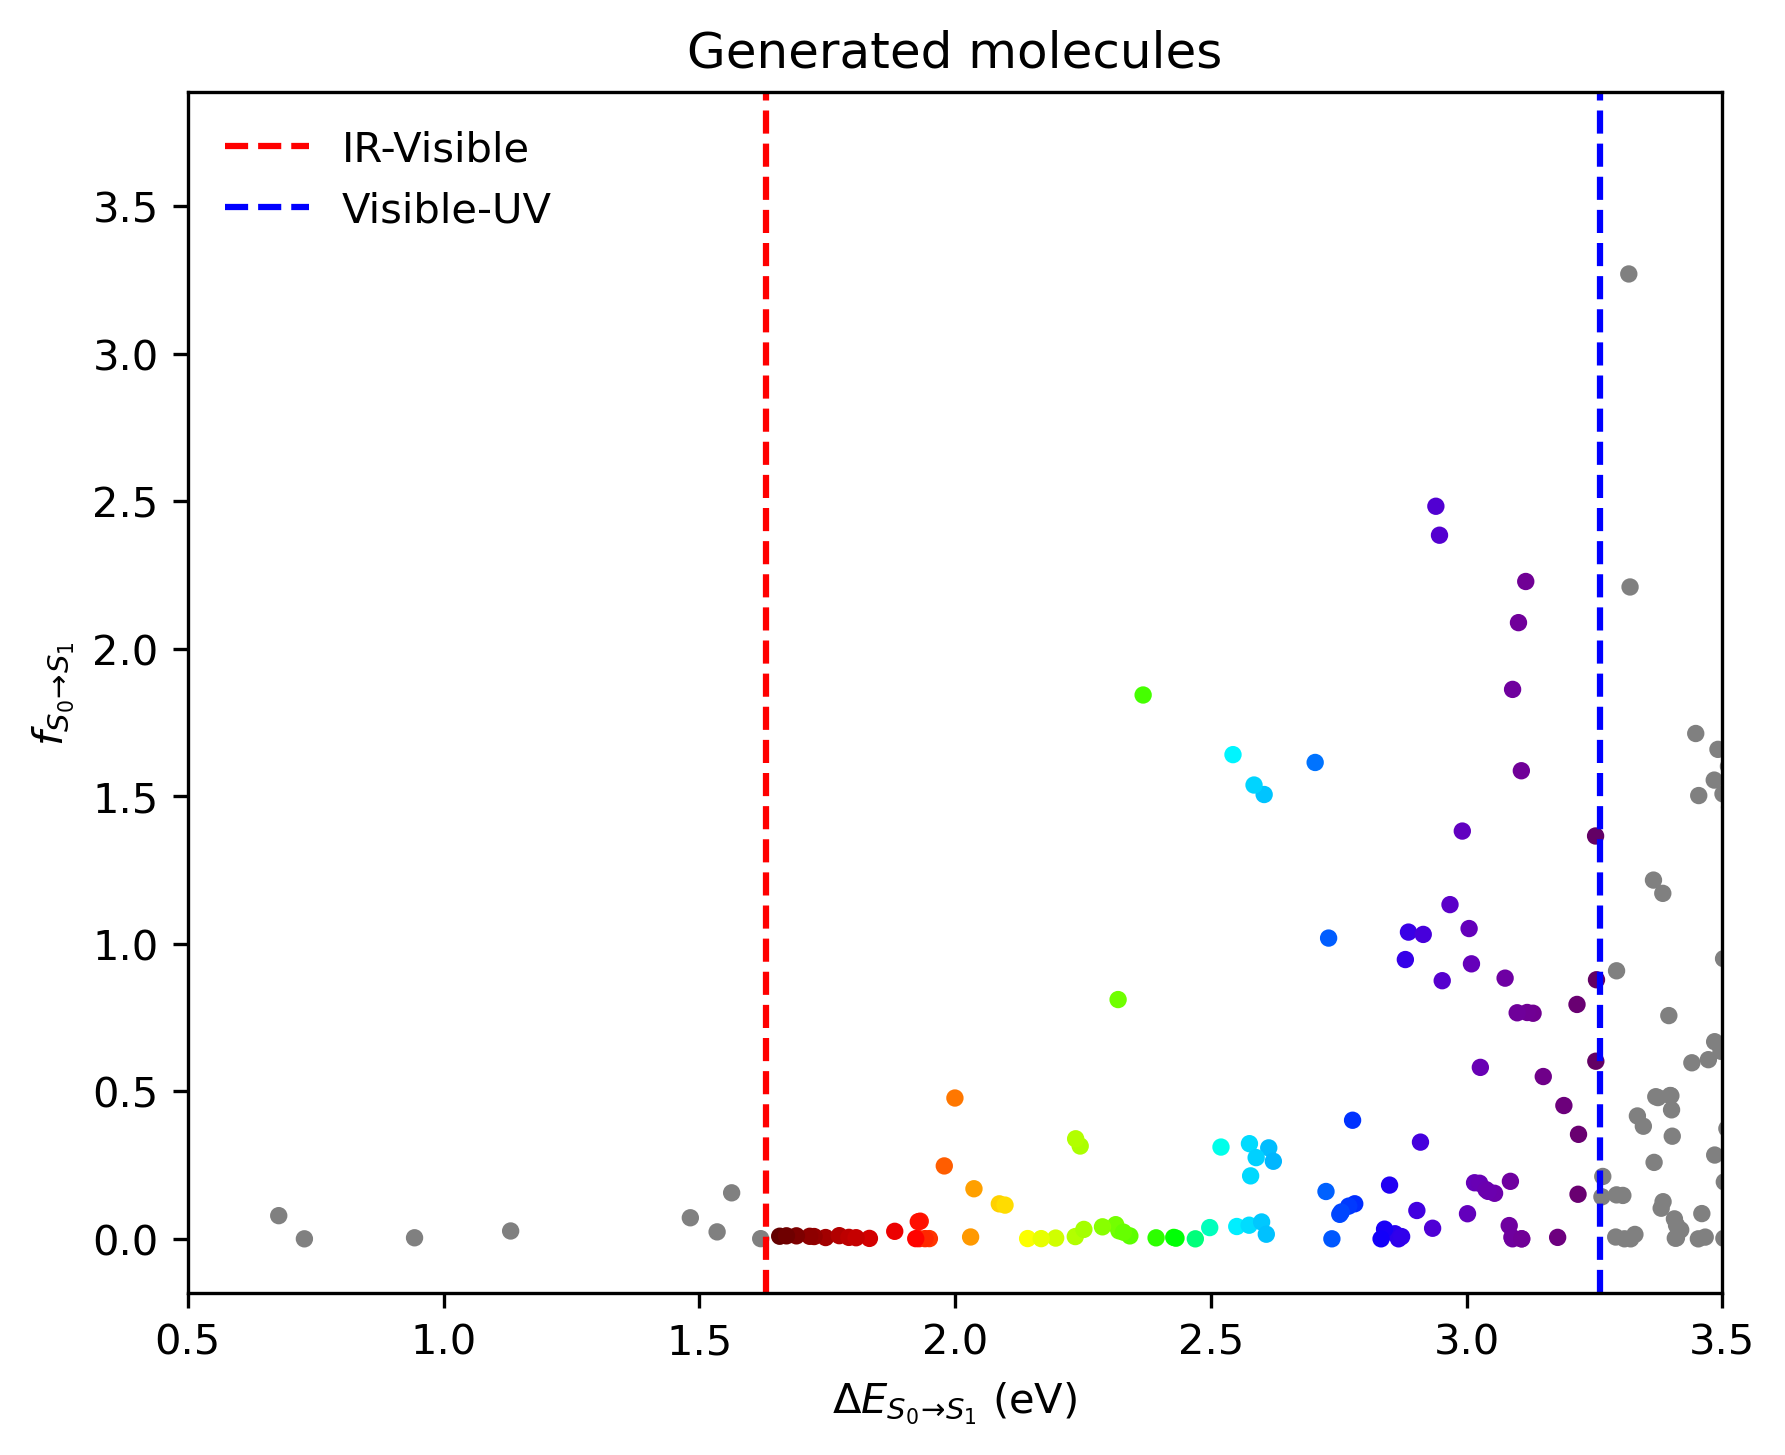

In [8]:
# plot the scatter plot of E_S1_SOC(eV) vs osc_S1_SOC and color the points by wavelength and put vertical lines at E_S1_SOC(eV) = 1.63 eV (IR-Visible) and in 3.26 eV (Visible-UV)
# use scatter_colored function defined above
fig, ax = scatter_colored(
    val_df,
    col_Es1="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated molecules",
    xlab=r"$\Delta E_{S_0\!\to\!S_1}$ (eV)",
    ylab=r"$f_{S_0\!\to\!S_1}$",
    xlim=(0, 5)
)
ax.axvline(1.63, color="red", linestyle="--", label="IR-Visible")
ax.axvline(3.26, color="blue", linestyle="--", label="Visible-UV")
ax.set_xlim(0.5, 3.5)
ax.legend(frameon=False)
plt.show()


In [7]:
# compute number of molecules generated in IR, visible and UV range
def classify_wavelength(energy_ev):
    if energy_ev < 1.63:
        return "IR"
    elif 1.63 <= energy_ev <= 3.26:
        return "Visible"
    else:
        return "UV"
val_df["wavelength_class"] = val_df["E_S1_SOC(eV)"].apply(classify_wavelength)
wavelength_counts = val_df["wavelength_class"].value_counts()
print(wavelength_counts)

wavelength_class
UV         337
Visible    113
IR           8
Name: count, dtype: int64


In [25]:
import numpy as np
import pandas as pd

def spectral_region_table(
    df: pd.DataFrame,
    col_E: str = "E_S1_SOC(eV)",
    *,
    dropna: bool = True,
    normalize: bool = True,
    include_ranges: bool = True,
    regions: list[dict] | None = None,
) -> pd.DataFrame:
    """
    Count molecules per electromagnetic spectral region based on transition energy (eV).

    Mapping uses wavelength λ (nm) = 1239.841984 / E(eV).

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing excitation energies.
    col_E : str
        Column name for energies in eV.
    dropna : bool
        Drop NaN energies.
    normalize : bool
        Add fraction (%) column.
    include_ranges : bool
        Add wavelength and energy range columns for each region.
    regions : list[dict] | None
        Custom regions. Each dict: {"name": str, "lo_nm": float|None, "hi_nm": float|None}
        where lo_nm is lower wavelength bound (inclusive) and hi_nm is upper bound (exclusive).
        Use None for open-ended bounds.

    Returns
    -------
    pd.DataFrame
        Columns: region, count, (fraction_%)
        Optional: lambda_range_nm, energy_range_eV
    """

    # Default region definitions (nm). Bounds: [lo, hi)
    # Note: these are conventional approximate boundaries.
    if regions is None:
        regions = [
            # Infrared
            {"name": "mid-IR (3–8 µm)",       "lo_nm": 3000.0, "hi_nm": 8000.0},
            {"name": "shortwave IR (1.4–3 µm)","lo_nm": 1400.0, "hi_nm": 3000.0},
            {"name": "NIR (0.75–1.4 µm)",     "lo_nm": 750.0,  "hi_nm": 1400.0},

            # Visible (often taken ~380–750 nm)
            {"name": "red (620–750 nm)",      "lo_nm": 620.0,  "hi_nm": 750.0},
            {"name": "orange (590–620 nm)",   "lo_nm": 590.0,  "hi_nm": 620.0},
            {"name": "yellow (570–590 nm)",   "lo_nm": 570.0,  "hi_nm": 590.0},
            {"name": "green (495–570 nm)",    "lo_nm": 495.0,  "hi_nm": 570.0},
            {"name": "blue (450–495 nm)",     "lo_nm": 450.0,  "hi_nm": 495.0},
            {"name": "violet (380–450 nm)",   "lo_nm": 380.0,  "hi_nm": 450.0},

            # Ultraviolet
            {"name": "near-UV (300–380 nm)",  "lo_nm": 300.0,  "hi_nm": 380.0},
            {"name": "UVB (280–300 nm)",      "lo_nm": 280.0,  "hi_nm": 300.0},
            {"name": "UVC (<280 nm)",         "lo_nm": None,   "hi_nm": 280.0},
        ]

    s = df[col_E]
    if dropna:
        s = s.dropna()

    # Keep only physically meaningful energies
    s = s[np.isfinite(s) & (s > 0.0)]
    N = int(s.shape[0])

    if N == 0:
        cols = ["region", "count"]
        if normalize:
            cols.append("fraction_%")
        if include_ranges:
            cols += ["lambda_range_nm", "energy_range_eV"]
        return pd.DataFrame(columns=cols)

    # λ (nm)
    lam_nm = 1239.841984 / s.to_numpy()

    out_rows = []
    for r in regions:
        lo = r.get("lo_nm", None)
        hi = r.get("hi_nm", None)

        mask = np.ones_like(lam_nm, dtype=bool)
        if lo is not None:
            mask &= lam_nm >= float(lo)
        if hi is not None:
            mask &= lam_nm < float(hi)

        c = int(mask.sum())

        row = {"region": r["name"], "count": c}
        if normalize:
            row["fraction_%"] = 100.0 * c / N

        if include_ranges:
            # wavelength range as text
            lo_txt = f"{lo:g}" if lo is not None else "-inf"
            hi_txt = f"{hi:g}" if hi is not None else "inf"
            row["lambda_range_nm"] = f"[{lo_txt}, {hi_txt})"

            # convert wavelength bounds to energy bounds (eV), remembering E = 1239.84/λ
            # For λ in [lo, hi): E in (1239.84/hi, 1239.84/lo]
            def nm_to_eV(x):
                return 1239.841984 / x

            E_low = nm_to_eV(hi) if hi is not None else 0.0          # open upper wavelength -> E_low = 0
            E_high = nm_to_eV(lo) if lo is not None else np.inf      # open lower wavelength -> E_high = inf
            if np.isfinite(E_high):
                row["energy_range_eV"] = f"({E_low:.3f}, {E_high:.3f}]"
            else:
                row["energy_range_eV"] = f"({E_low:.3f}, inf]"

        out_rows.append(row)

    res = pd.DataFrame(out_rows)

    # Add a catch-all "unclassified" (e.g., far-IR > 8 µm or any gaps)
    classified = np.zeros_like(lam_nm, dtype=bool)
    for r in regions:
        lo = r.get("lo_nm", None)
        hi = r.get("hi_nm", None)
        m = np.ones_like(lam_nm, dtype=bool)
        if lo is not None:
            m &= lam_nm >= float(lo)
        if hi is not None:
            m &= lam_nm < float(hi)
        classified |= m

    unc = int((~classified).sum())
    if unc > 0:
        row = {"region": "unclassified (outside defined ranges)", "count": unc}
        if normalize:
            row["fraction_%"] = 100.0 * unc / N
        if include_ranges:
            row["lambda_range_nm"] = ""
            row["energy_range_eV"] = ""
        res = pd.concat([res, pd.DataFrame([row])], ignore_index=True)

    # Optional: add total
    total_row = {"region": "TOTAL", "count": N}
    if normalize:
        total_row["fraction_%"] = 100.0
    if include_ranges:
        total_row["lambda_range_nm"] = ""
        total_row["energy_range_eV"] = ""
    res = pd.concat([res, pd.DataFrame([total_row])], ignore_index=True)

    return res


# Example usage:
table = spectral_region_table(val_df, col_E="E_S1_SOC(eV)")
print(table)

                     region  count  fraction_% lambda_range_nm energy_range_eV
0           mid-IR (3–8 µm)      0    0.000000    [3000, 8000)  (0.155, 0.413]
1   shortwave IR (1.4–3 µm)      2    0.436681    [1400, 3000)  (0.413, 0.886]
2         NIR (0.75–1.4 µm)      6    1.310044     [750, 1400)  (0.886, 1.653]
3          red (620–750 nm)     19    4.148472      [620, 750)  (1.653, 2.000]
4       orange (590–620 nm)      4    0.873362      [590, 620)  (2.000, 2.101]
5       yellow (570–590 nm)      2    0.436681      [570, 590)  (2.101, 2.175]
6        green (495–570 nm)     17    3.711790      [495, 570)  (2.175, 2.505]
7         blue (450–495 nm)     19    4.148472      [450, 495)  (2.505, 2.755]
8       violet (380–450 nm)     52   11.353712      [380, 450)  (2.755, 3.263]
9      near-UV (300–380 nm)    192   41.921397      [300, 380)  (3.263, 4.133]
10         UVB (280–300 nm)     57   12.445415      [280, 300)  (4.133, 4.428]
11            UVC (<280 nm)     88   19.213974     [

SMILES: CC1=c2c(ccc3ccccc23)=c2c(c3c(c4ccccc24)=CC=C3)C1=O, Energy: 1.56 eV, Strength: 0.156


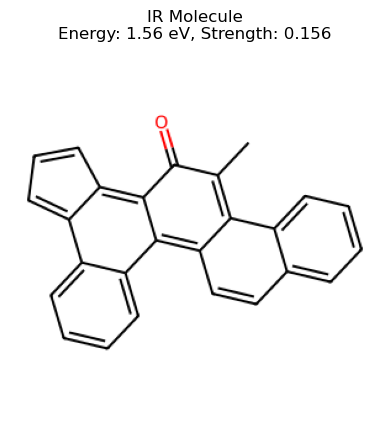

SMILES: C1=Cc2ccc3c(c2=C1)=CC=C3, Energy: 1.53 eV, Strength: 0.024


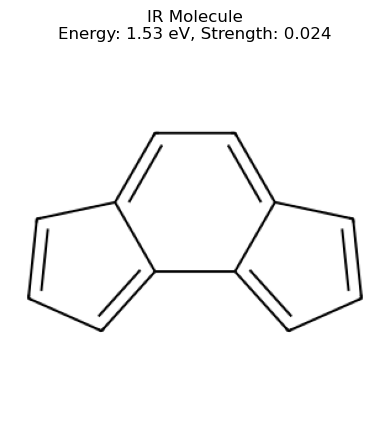

SMILES: COCCC1=CC2=NC1=CC=c1[nH]c(cc1CCOC)=C1C=C(C)C(=N1)c1[nH]c2cc1CCOC, Energy: 1.48 eV, Strength: 0.071


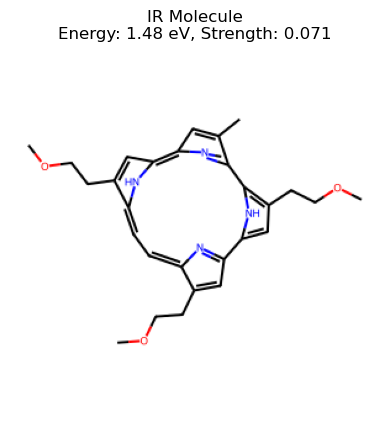

SMILES: CC1=CC=c2c1ccc1ccc3c(c21)C=CC=3, Energy: 1.13 eV, Strength: 0.027


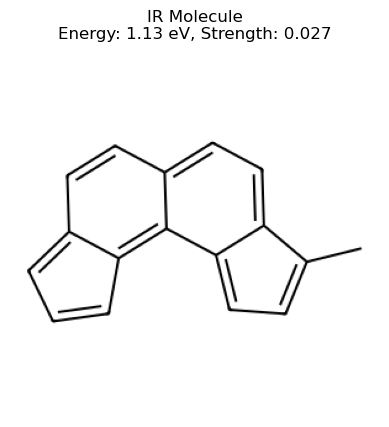

SMILES: CC1=c2c(nc3c4ccccc4c4cccc4n23)C=C1, Energy: 0.94 eV, Strength: 0.004


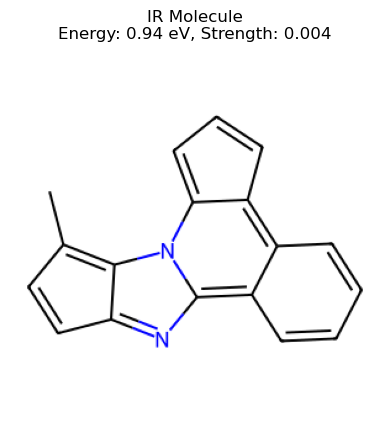

SMILES: [As]c1nc2ccccc2o1, Energy: 0.73 eV, Strength: 0.000


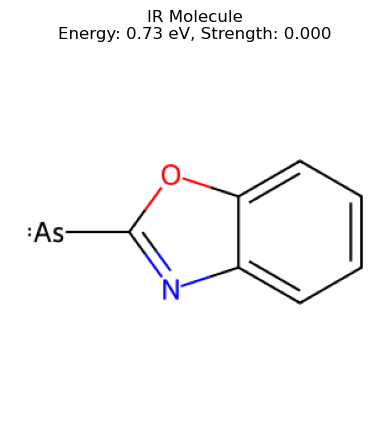

SMILES: FC1=CC=C2C=CC=C12, Energy: 1.62 eV, Strength: 0.001


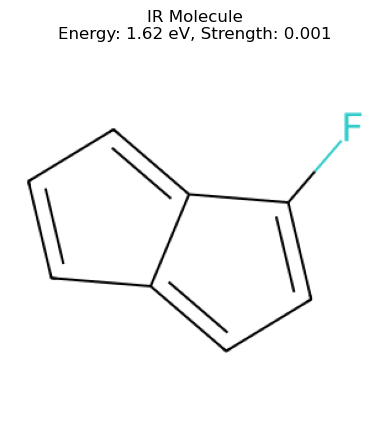

SMILES: CCOc1ccc2c3c(c(OC)ccc13)C=CC=c1c3cccc(c3-2)c2ccccc12, Energy: 0.68 eV, Strength: 0.079


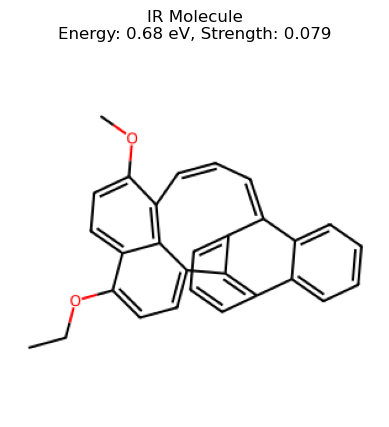

In [9]:
# give me the smiles of the IR molecules and plot the sketch using rdkit
from rdkit import Chem
from rdkit.Chem import Draw
ir_molecules = val_df[val_df["wavelength_class"] == "IR"]
for idx, row in ir_molecules.iterrows():
    smiles = row["smiles"]
    energy = row["E_S1_SOC(eV)"]
    strength = row["osc_S1_SOC"]
    print(f"SMILES: {smiles}, Energy: {energy:.2f} eV, Strength: {strength:.3f}")
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        img = Draw.MolToImage(mol, size=(300, 300))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"IR Molecule\nEnergy: {energy:.2f} eV, Strength: {strength:.3f}")
        plt.show()
    

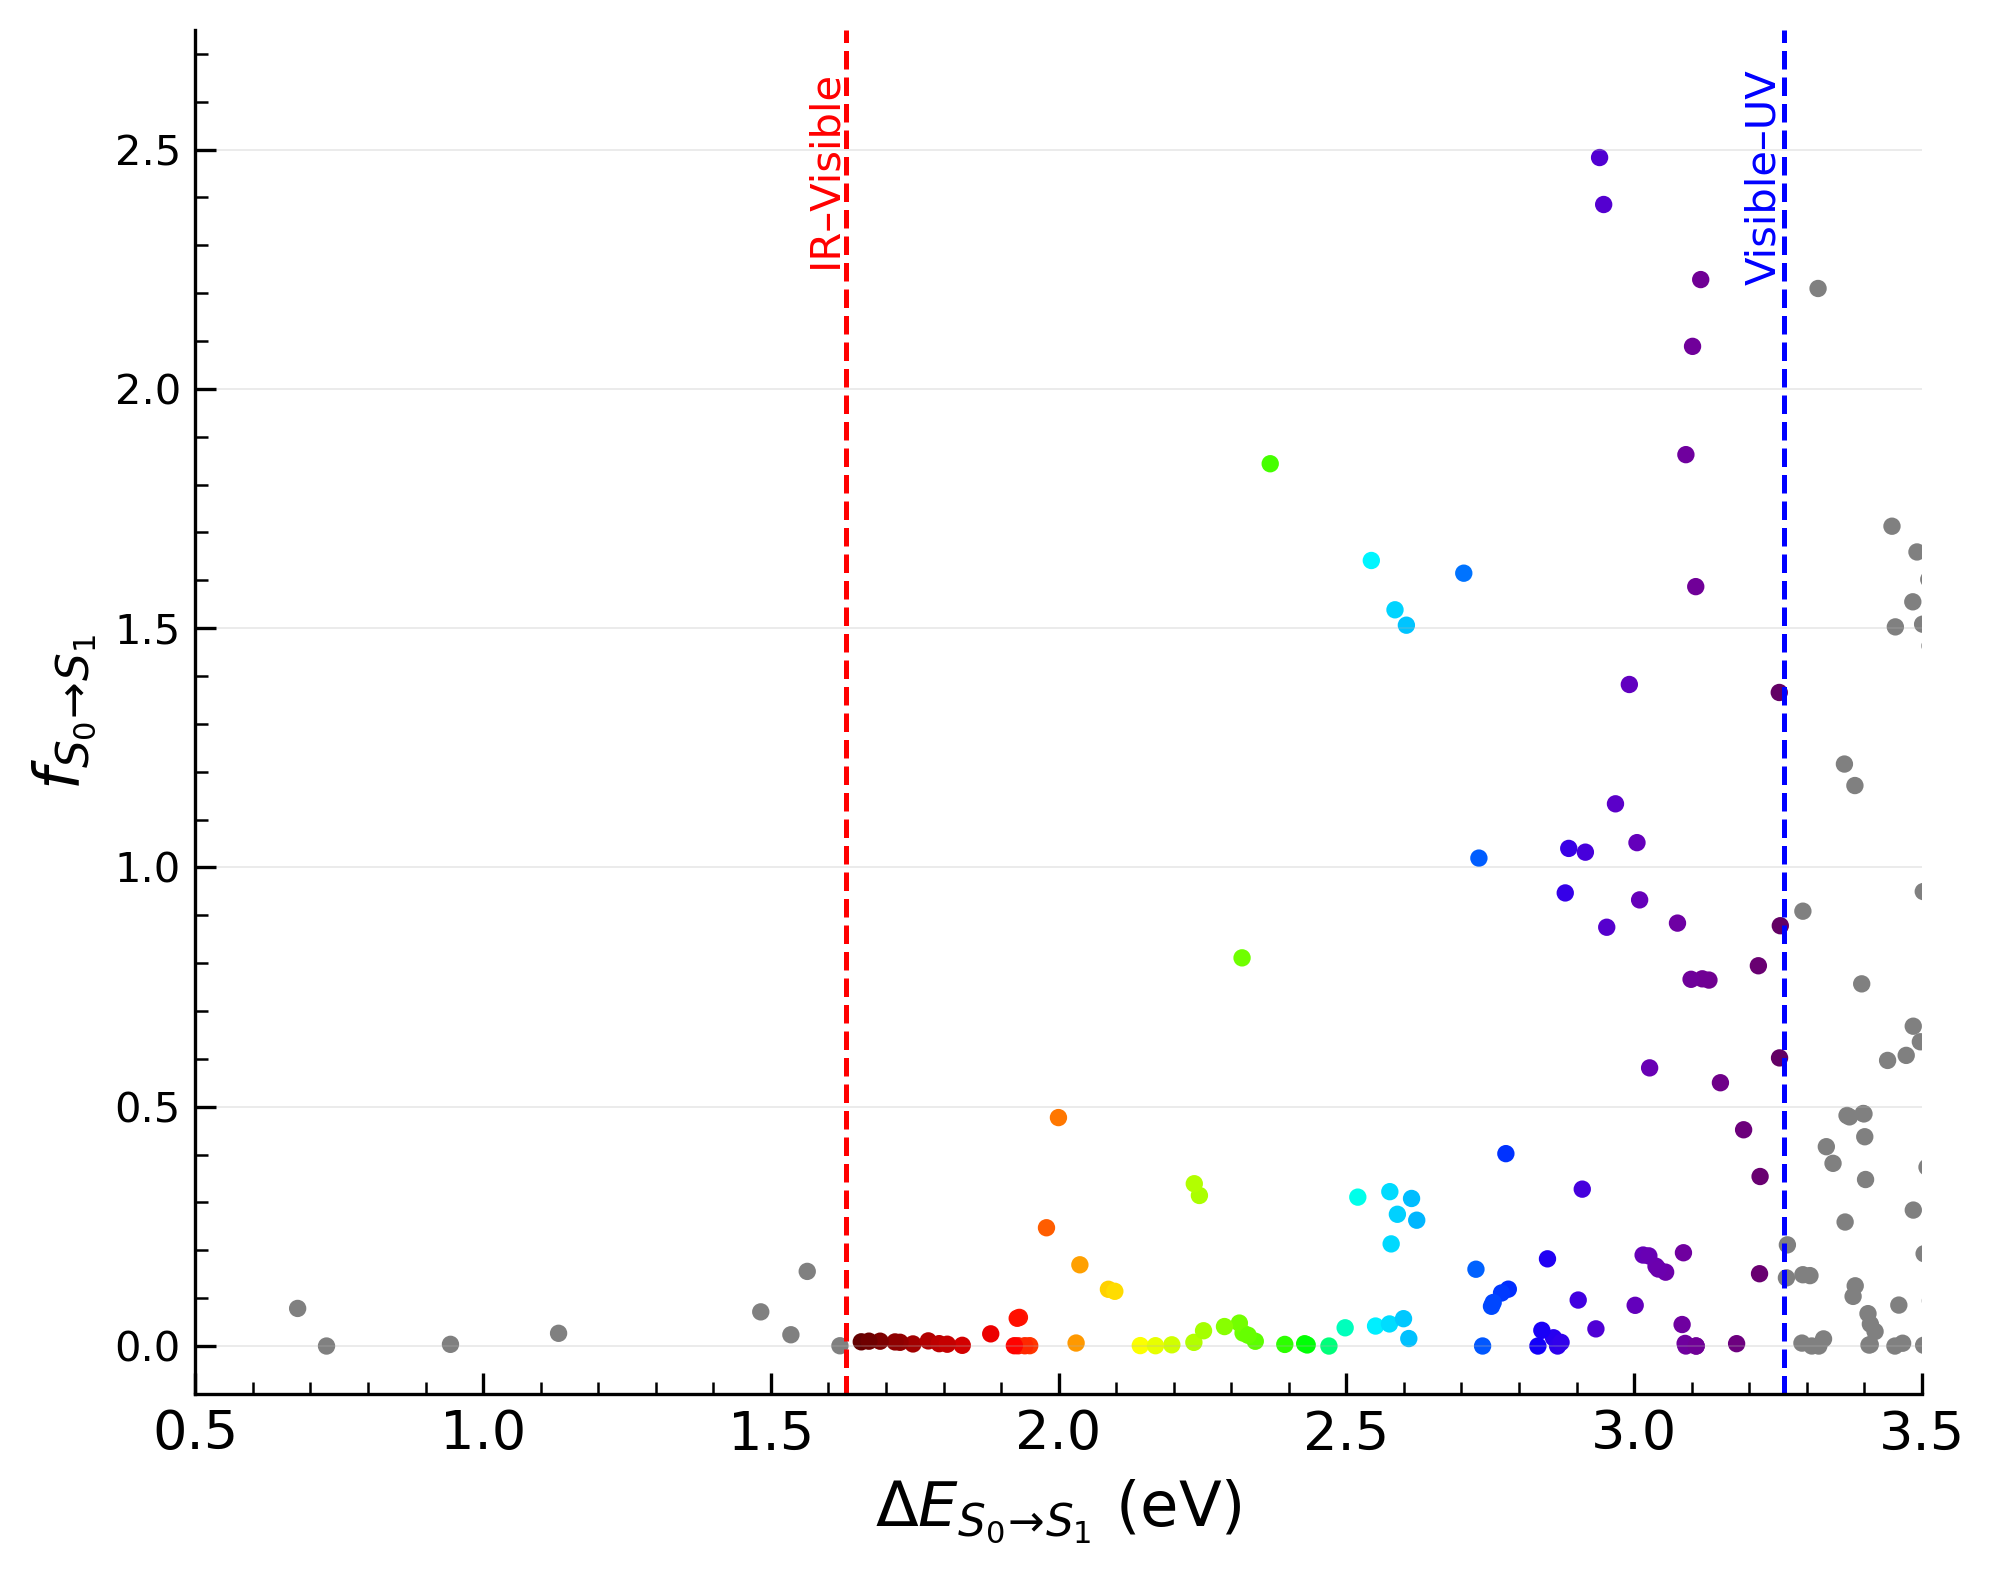

Saved: plots_for_manuscript/validation_optical_properties/generated_molecules_scatter.pdf


In [48]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- publication-ready defaults ---
mpl.rcParams.update({
    "figure.figsize": (3, 3),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "legend.fontsize": 8,
    "xtick.labelsize": 13,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3.0,
    "ytick.minor.size": 3.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

outdir = "plots_for_manuscript/validation_optical_properties"
os.makedirs(outdir, exist_ok=True)
outfile = os.path.join(outdir, "generated_molecules_scatter.pdf")

fig, ax = scatter_colored(
    val_df,
    col_Es1="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="",
    xlab=r"$\Delta E_{S_0\!\to\!S_1}$ (eV)",
    ylab=r"$f_{S_0\!\to\!S_1}$",
    xlim=(0.5, 3.5),
    
)

# cleaner axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

# optional: light y-grid (keeps scatter readable)
ax.grid(True, axis="y", linewidth=0.4, alpha=0.3)
ax.grid(False, axis="x")


# vertical boundaries (use annotations instead of legend)
ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)
ax.set_ylim(-0.1, 2.75)
ymax = ax.get_ylim()[1]
ax.text(1.63, 0.97 * ymax, "IR–Visible", color="red",
        rotation=90, va="top", ha="right", fontsize=10)
ax.text(3.26, 0.97 * ymax, "Visible–UV", color="blue",
        rotation=90, va="top", ha="right", fontsize=10)

# tighten + save
fig.tight_layout(pad=0.6)
fig.savefig(outfile, bbox_inches="tight", transparent=True)
plt.show()

print(f"Saved: {outfile}")

In [39]:
!mkdir -p rdkit_sa
!wget -O rdkit_sa/sascorer.py https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!wget -O rdkit_sa/fpscores.pkl.gz https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

--2026-02-25 11:01:50--  https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5913 (5,8K) [text/plain]
Saving to: ‘rdkit_sa/sascorer.py’

rdkit_sa/sascorer.p 100%[===================>]   5,77K  --.-KB/s    in 0,001s  

2026-02-25 11:01:50 (9,55 MB/s) - ‘rdkit_sa/sascorer.py’ saved [5913/5913]

--2026-02-25 11:01:51--  https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 38483

In [40]:
import os
import importlib.util
import pandas as pd
from rdkit import Chem

def load_sascorer(sa_dir="rdkit_sa"):
    sascorer_path = os.path.join(sa_dir, "sascorer.py")
    fpscores_path = os.path.join(sa_dir, "fpscores.pkl.gz")

    if not os.path.exists(sascorer_path):
        raise FileNotFoundError(f"Missing: {sascorer_path}")
    if not os.path.exists(fpscores_path):
        raise FileNotFoundError(f"Missing: {fpscores_path}")

    spec = importlib.util.spec_from_file_location("sascorer", sascorer_path)
    sascorer = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(sascorer)

    # Ensure sascorer can find fpscores.pkl.gz (it looks relative to its own location)
    # This is already satisfied by placing fpscores.pkl.gz in the same folder.
    return sascorer

def add_sa_score_column(df, smiles_col, sa_dir="rdkit_sa", out_col="SA_score"):
    sascorer = load_sascorer(sa_dir)

    def _sa(smiles):
        m = Chem.MolFromSmiles(smiles)
        return float(sascorer.calculateScore(m)) if m is not None else float("nan")

    df = df.copy()
    df[out_col] = df[smiles_col].map(_sa)
    return df

# Example:
val_df = add_sa_score_column(val_df, smiles_col="smiles", sa_dir="rdkit_sa", out_col="SA_score")

458

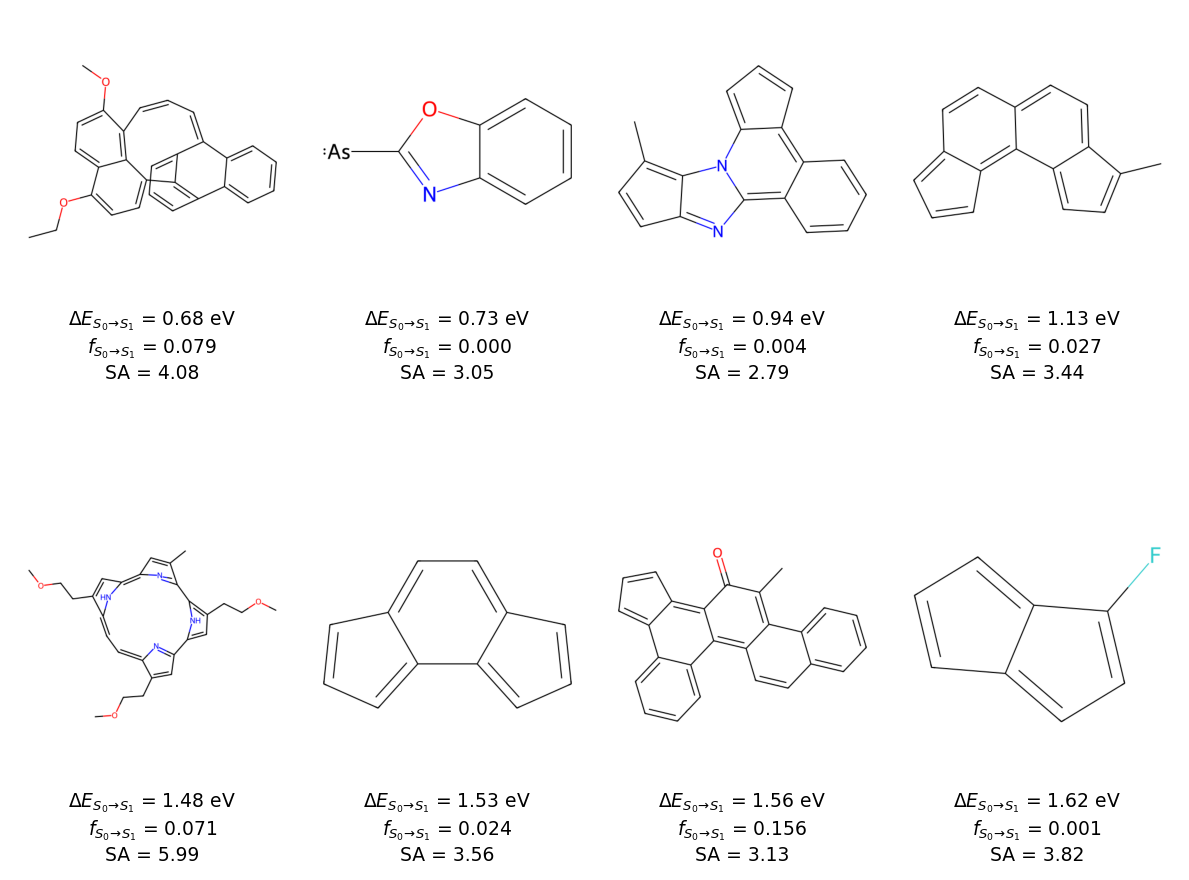

Saved: plots_for_manuscript/validation_optical_properties/SI_ir_molecules_grid_with_SA.pdf
Saved: plots_for_manuscript/validation_optical_properties/SI_ir_molecules_ranked_with_SA.csv


In [45]:
import os
import math
import importlib.util

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw


# -----------------------------
# Load RDKit Contrib SA scorer
# (expects: rdkit_sa/sascorer.py and rdkit_sa/fpscores.pkl.gz)
# -----------------------------
def load_sascorer(sa_dir="rdkit_sa"):
    sascorer_path = os.path.join(sa_dir, "sascorer.py")
    fpscores_path = os.path.join(sa_dir, "fpscores.pkl.gz")

    if not os.path.exists(sascorer_path):
        raise FileNotFoundError(f"Missing: {sascorer_path}")
    if not os.path.exists(fpscores_path):
        raise FileNotFoundError(f"Missing: {fpscores_path}")

    spec = importlib.util.spec_from_file_location("sascorer", sascorer_path)
    sascorer = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(sascorer)

    return sascorer


def compute_sa_scores(df, smiles_col, sa_dir="rdkit_sa", out_col="SA_score"):
    sascorer = load_sascorer(sa_dir)

    def _sa(smi):
        m = Chem.MolFromSmiles(smi)
        return float(sascorer.calculateScore(m)) if m is not None else np.nan

    out = df.copy()
    out[out_col] = out[smiles_col].map(_sa)
    return out


def mol2d(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    Chem.rdDepictor.Compute2DCoords(m)
    return m


# -----------------------------
# Publication-ish matplotlib defaults
# -----------------------------
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# -----------------------------
# Identify SMILES column
# -----------------------------
E_col = "E_S1_SOC(eV)"
f_col = "osc_S1_SOC"
smiles_candidates = ["smiles", "SMILES", "canonical_smiles", "Smiles", "smile"]
smiles_col = next((c for c in smiles_candidates if c in val_df.columns), None)
if smiles_col is None:
    raise ValueError(f"Could not find a SMILES column in val_df. Tried: {smiles_candidates}")


# -----------------------------
# Filter IR, order by energy, take 8
# -----------------------------
ir_df = (
    val_df[[smiles_col, E_col, f_col]]
    .dropna()
    .query(f"`{E_col}` < 1.63")
    .sort_values(E_col, ascending=True)
    .drop_duplicates(subset=[smiles_col], keep="first")
    .reset_index(drop=True)
)

if len(ir_df) < 8:
    raise ValueError(f"Expected 8 IR molecules, found {len(ir_df)} after filtering/dedup.")

ir_df = ir_df.iloc[:8].copy()

# SA score (canonical sascorer)
ir_df = compute_sa_scores(ir_df, smiles_col=smiles_col, sa_dir="rdkit_sa", out_col="SA_score")


# -----------------------------
# Build SI grid: 8 molecules on an 8×8 inch canvas
# (2 rows × 4 cols panels)
# -----------------------------
mols = [mol2d(s) for s in ir_df[smiles_col].tolist()]

n = len(mols)
ncols = 4
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 8))
axes = np.atleast_2d(axes)

for ax in axes.ravel():
    ax.set_axis_off()

for i, (mol, (_, row)) in enumerate(zip(mols, ir_df.iterrows())):
    r = i // ncols
    c = i % ncols
    ax = axes[r, c]

    if mol is None:
        ax.text(0.5, 0.5, "Invalid SMILES", ha="center", va="center", fontsize=9)
        continue

    img = Draw.MolToImage(mol, size=(500, 500))
    ax.imshow(img)

    E = float(row[E_col])
    ff = float(row[f_col])
    sa = float(row["SA_score"]) if np.isfinite(row["SA_score"]) else np.nan

    ax.text(
        0.5, -0.07,
        rf"$\Delta E_{{S_0\!\to\!S_1}}$ = {E:.2f} eV" + "\n" + rf"$f_{{S_0\!\to\!S_1}}$ = {ff:.3f}" + "\n" + rf"SA = {sa:.2f}",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=9
    )

# hide unused panels (should not happen here)
for j in range(n, nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])

# -----------------------------
# Save
# -----------------------------
outdir = "plots_for_manuscript/validation_optical_properties"
os.makedirs(outdir, exist_ok=True)

pdf_path = os.path.join(outdir, "SI_ir_molecules_grid_with_SA.pdf")
csv_path = os.path.join(outdir, "SI_ir_molecules_ranked_with_SA.csv")

fig.savefig(pdf_path, bbox_inches="tight", transparent=True)
plt.show()

ir_df.to_csv(csv_path, index=False)

print(f"Saved: {pdf_path}")
print(f"Saved: {csv_path}")